In [82]:
source("./src/slingshot_functions.r")
library(qs)

In [6]:
#seurat_obj <- readRDS("../Data/in/seurat_obj/p3f_dosages_2wks.rds")
#seurat_obj

In [5]:
#options(repr.plot.width=10, repr.plot.height=8)
#DimPlot(seurat_obj, group.by="subclusters_2", label=TRUE)

In [7]:
#seurat_obj <- SetIdent(seurat_obj, value="subclusters_2")

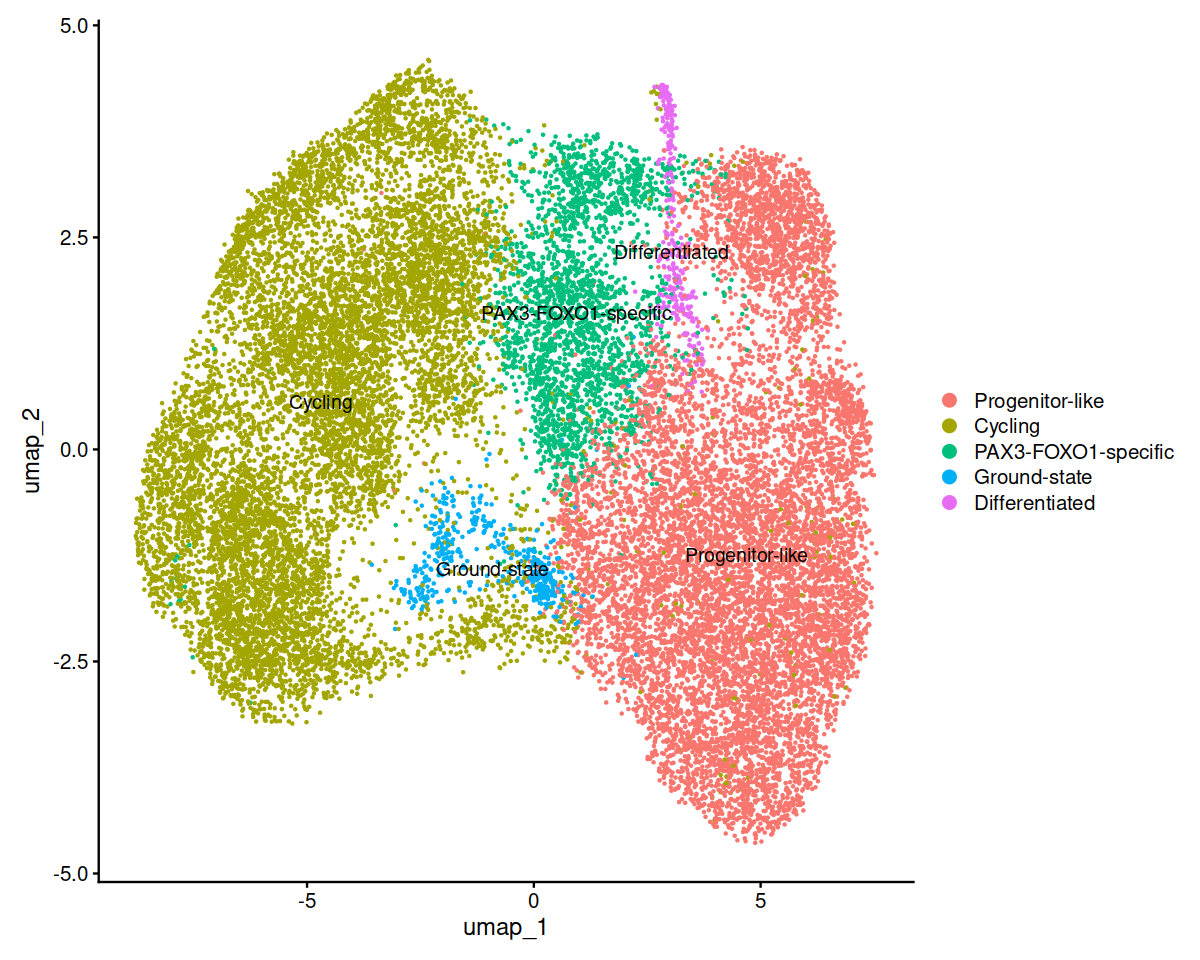

In [13]:
options(repr.plot.width=10, repr.plot.height=8)
seurat_obj <- qread("../Data/out/seurat_phase1_annotated.qs")
seurat_obj <- SetIdent(seurat_obj, value="cell_label")
DimPlot(seurat_obj, label=TRUE)

In [10]:
unique(seurat_obj@meta.data$sample_names)

[1] "0 ng/mL, 2 wks"   "500 ng/mL, 2 wks" "75 ng/mL, 2 wks"

In [20]:
table(seurat_obj@meta.data$cell_label, seurat_obj@meta.data$orig.ident)

                     
                      SeuratProject
  Progenitor-like              9977
  Cycling                     10673
  PAX3-FOXO1-specific          2450
  Ground-state                  466
  Differentiated                304

In [16]:
singlecell_obj <- as.SingleCellExperiment(seurat_obj, assay='RNA')
singlecell_obj

class: SingleCellExperiment 
dim: 20080 23870 
metadata(0):
assays(2): counts logcounts
rownames(20080): AL627309.5 LINC01409 ... AC245140.1 LINC00266-4P
rowData names(0):
colnames(23870): Dbt-0-2wk_AAACCCAAGGTAGCAC-1_2_1_1
  Dbt-0-2wk_AAACCCACAAGAGGTC-1_2_1_1 ...
  Dbt-75-2wk_TTTGTTGTCATTCGGA-1_2 Dbt-75-2wk_TTTGTTGTCATTTCCA-1_2
colData names(53): orig.ident nCount_RNA ... AP.1.expressing_Score.2
  ident
reducedDimNames(3): PCA HARMONY UMAP
mainExpName: RNA
altExpNames(0):

In [76]:
options(repr.plot.width = 12, repr.plot.height = 10)
slingshot_obj <- slingshot(singlecell_obj, 
                           clusterLabels    = "cell_label", 
                           reducedDim       = "UMAP", 
                           start.clus       = "Progenitor-like",
                           end.clus       = c("Cycling","Ground-state",'Differentiated'),
                           shrink        = 0.99,
                           extend        = "n",
                           allow.breaks  = TRUE,
                           stretch       = 0.0,
                           thresh        = 0.001
                          )

slingLineages(slingshot_obj)

$Lineage1
[1] "Progenitor-like"     "PAX3-FOXO1-specific" "Cycling"            

$Lineage2
[1] "Progenitor-like"     "PAX3-FOXO1-specific" "Ground-state"       

$Lineage3
[1] "Progenitor-like"     "PAX3-FOXO1-specific" "Differentiated"

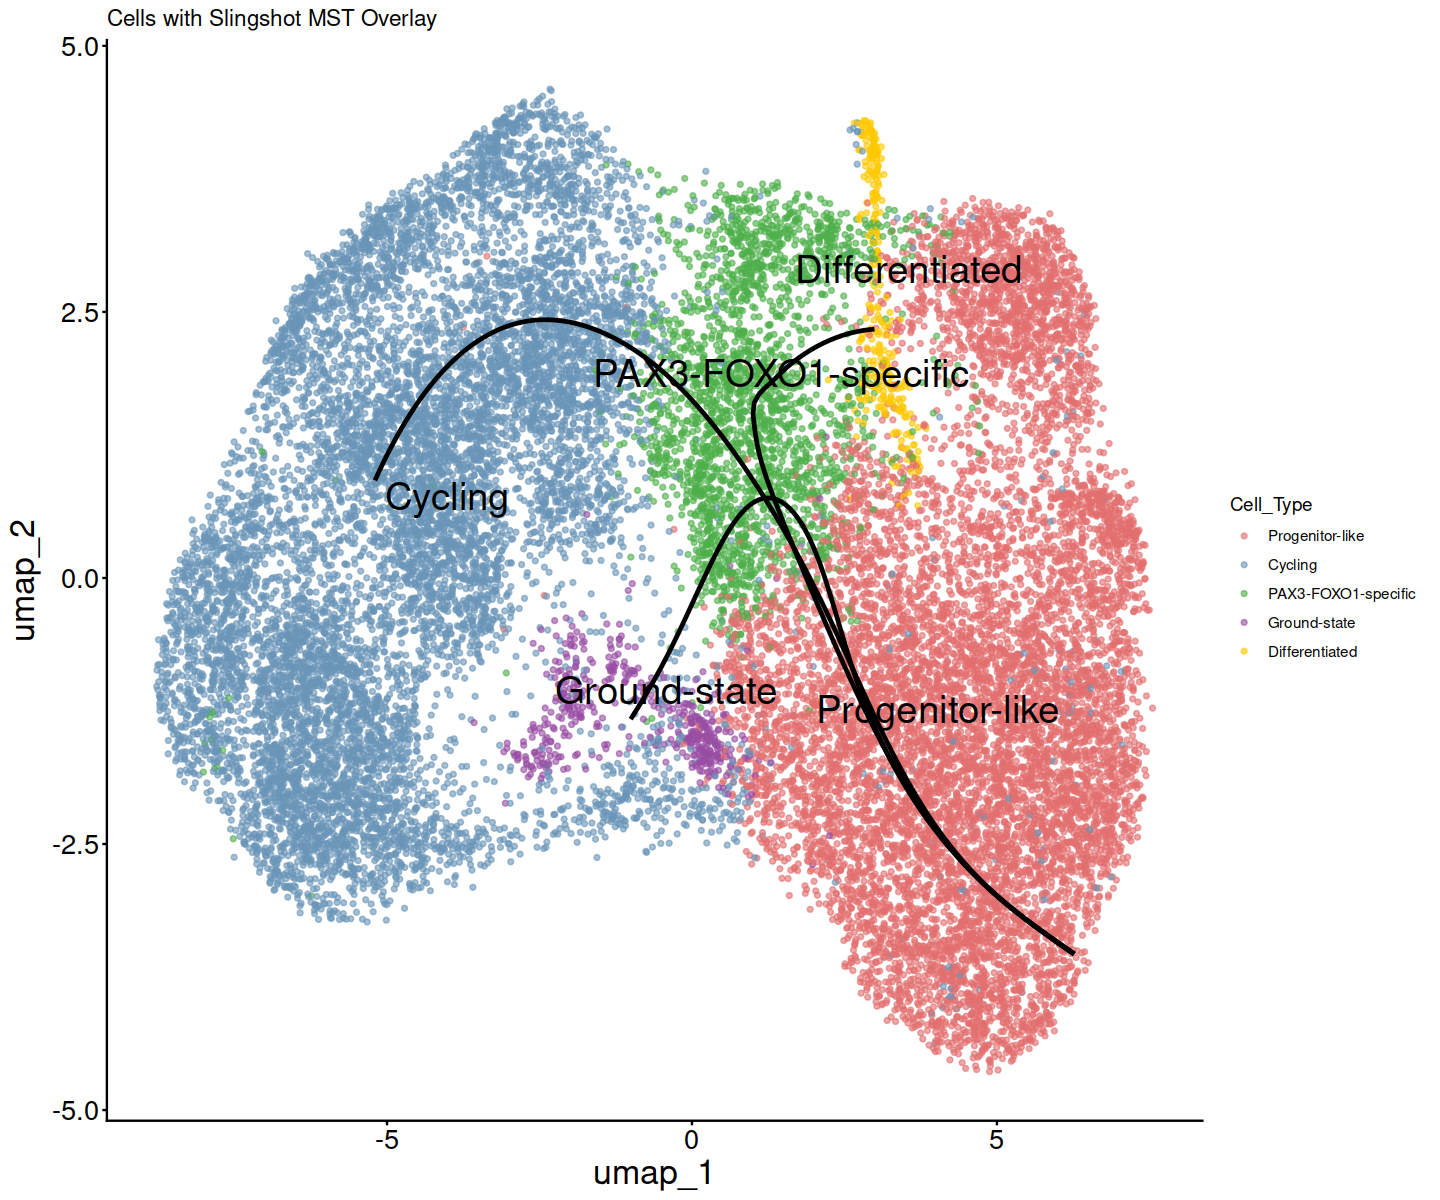

In [91]:
cluster_colors <- c(
  "Progenitor-like" = "#E36f6f",
  "Cycling" = "#6A95B8",
  "PAX3-FOXO1-specific" = "#4DAF4A",
  "Ground-state" = "#984EA3",
  "Differentiated" = "#FFC800"
)

cell_plot <- plot_slingshot_trajectory_trimmed(
  seurat_obj,
  slingshot_obj,
  annot_column = "cell_label",
  cluster_colors = cluster_colors,
  point_size = 1.0,
  point_alpha = 0.6
)

ggsave(
  "./out/slingshot_trajectory_phase1.png",
  plot = cell_plot,
  width = 8,
  height = 6,
  dpi = 300
)

cell_plot

In [78]:
qsave(slingshot_obj, "./out/slingshot_obj_phase1.qs")

In [79]:
slingshot_obj

class: SingleCellExperiment 
dim: 20080 23870 
metadata(0):
assays(2): counts logcounts
rownames(20080): AL627309.5 LINC01409 ... AC245140.1 LINC00266-4P
rowData names(0):
colnames(23870): Dbt-0-2wk_AAACCCAAGGTAGCAC-1_2_1_1
  Dbt-0-2wk_AAACCCACAAGAGGTC-1_2_1_1 ...
  Dbt-75-2wk_TTTGTTGTCATTCGGA-1_2 Dbt-75-2wk_TTTGTTGTCATTTCCA-1_2
colData names(57): orig.ident nCount_RNA ... slingPseudotime_2
  slingPseudotime_3
reducedDimNames(3): PCA HARMONY UMAP
mainExpName: RNA
altExpNames(0):